# XGBoost — Per-Motor Current Prediction (Power Limiter)

| Property | Value |
|----------|-------|
| **Model** | 4 x XGBoost (one per motor, shared features) |
| **Features** | I_FL/FR/RL/RR lags, T_sum lags, U_dc |
| **Target** | I_FL, I_FR, I_RL, I_RR at t+1 |
| **Split** | by run_id (first 70% = train) |

Hyperparameters tuned on FL motor via RandomizedSearchCV, then reused for all 4 motors.

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path().resolve()
SRC_DIR  = _cwd if (_cwd / 'functions').exists() else _cwd / 'src'
DATA_DIR = SRC_DIR.parent / 'data' / 'model'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DT            = 0.2        # 5 Hz sample rate
N_LAGS        = 5          # 1 s lookback (5 ticks × 0.2 s)
POWER_LIMIT_W = 80_000
MOTOR_NAMES   = ['FL', 'FR', 'RL', 'RR']
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from functions.evaluation import display_model_results, compare_models

print(f'XGBoost  : {xgb.__version__}')
print(f'DATA_DIR : {DATA_DIR}')


XGBoost  : 3.2.0
DATA_DIR : /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/data/model


## 1. Data Loading and Feature Engineering

In [2]:
df = pd.read_csv(DATA_DIR / 'training_data.csv')
df = df.sort_values(['run_id', 'timestamp_s']).reset_index(drop=True)
df['T_sum'] = df['T_FL'] + df['T_FR'] + df['T_RL'] + df['T_RR']

# Run-safe lag features (no cross-run leakage)
for m in MOTOR_NAMES:
    for lag in range(1, N_LAGS + 1):
        df[f'I_{m}_lag{lag}'] = df.groupby('run_id')[f'I_{m}'].shift(lag)
for lag in range(1, N_LAGS + 1):
    df[f'T_sum_lag{lag}'] = df.groupby('run_id')['T_sum'].shift(lag)

# 1-step-ahead target (within each run)
for m in MOTOR_NAMES:
    df[f'I_{m}_next'] = df.groupby('run_id')[f'I_{m}'].shift(-1)

df_clean = df.dropna().reset_index(drop=True)
print(f'Loaded  : {len(df):,} rows, {df["run_id"].nunique()} runs')
print(f'Clean   : {len(df_clean):,} rows after dropna')


Loaded  : 5,693 rows, 10 runs
Clean   : 5,633 rows after dropna


In [3]:
runs         = sorted(df_clean['run_id'].unique())
n_train_runs = max(1, int(len(runs) * 0.70))
train_runs   = runs[:n_train_runs]
test_runs    = runs[n_train_runs:]

df_train = df_clean[df_clean['run_id'].isin(train_runs)].reset_index(drop=True)
df_test  = df_clean[df_clean['run_id'].isin(test_runs)].reset_index(drop=True)

y_train = df_train[[f'I_{m}_next' for m in MOTOR_NAMES]].values   # (n, 4)
y_test  = df_test[[f'I_{m}_next'  for m in MOTOR_NAMES]].values
U_test  = df_test['U_dc'].values
t_test  = df_test['timestamp_s'].values

print(f'Train runs : {train_runs}  ({len(df_train):,} samples)')
print(f'Test  runs : {test_runs}   ({len(df_test):,} samples)')
print(f'y_train    : {y_train.shape}')


Train runs : [2, 3, 4, 5, 6, 7, 8]  (3,730 samples)
Test  runs : [9, 10, 11]   (1,903 samples)
y_train    : (3730, 4)


In [4]:
# Shared feature matrix for all 4 motors
feature_cols = []
for m in MOTOR_NAMES:
    feature_cols.append(f'I_{m}')           # current value at t
    for lag in range(1, N_LAGS + 1):
        feature_cols.append(f'I_{m}_lag{lag}')
feature_cols.append('T_sum')
for lag in range(1, N_LAGS + 1):
    feature_cols.append(f'T_sum_lag{lag}')
feature_cols.append('U_dc')

X_train = df_train[feature_cols].values
X_test  = df_test[feature_cols].values
print(f'Features : {len(feature_cols)}   X_train: {X_train.shape}')


Features : 31   X_train: (3730, 31)


## 2. Training — RandomizedSearchCV on FL, reuse for FR/RL/RR

In [5]:
param_grid = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
}

base = xgb.XGBRegressor(
    objective='reg:squarederror', tree_method='hist',
    random_state=42, n_jobs=-1,
)
search = RandomizedSearchCV(
    base, param_grid, n_iter=20, scoring='neg_root_mean_squared_error',
    cv=3, random_state=42, verbose=1, n_jobs=-1,
)

t0 = time.perf_counter()
search.fit(X_train, y_train[:, 0])   # tune on FL
t_tune = time.perf_counter() - t0
best_params = search.best_params_

print(f'Tuning done in {t_tune:.1f} s')
print(f'Best CV RMSE : {-search.best_score_:.2f} A')
print(f'Best params  : {best_params}')


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning done in 6.5 s
Best CV RMSE : 1649.31 A
Best params  : {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [6]:
models = {}
t0 = time.perf_counter()
for j, m in enumerate(MOTOR_NAMES):
    xgb_m = xgb.XGBRegressor(
        **best_params, objective='reg:squarederror',
        tree_method='hist', random_state=42, n_jobs=-1,
    )
    xgb_m.fit(X_train, y_train[:, j])
    models[m] = xgb_m
    print(f'  Motor {m} trained')
t_train = time.perf_counter() - t0
print(f'Total training: {t_train:.1f} s')


  Motor FL trained
  Motor FR trained
  Motor RL trained
  Motor RR trained
Total training: 0.4 s


## 3. Evaluation

  MODEL: XGBoost 4-motor
  R2              : 0.5887
  RMSE            : 5682.57 A
  MAE             : 2501.58 A
  MedAE           : 748.55 A
  MAPE            : 100.73 %
  R2 per motor    : FL=0.590  FR=0.601  RL=0.579  RR=0.573
--------------------------------------------------------
  Under-pred.     : 33.2 % of samples
  Mean under-pred.: 3845.61 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 10874.90 kW
  Real violations : 1903 events > 80 kW
  Missed (FN)     : 16   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 99.2 %
--------------------------------------------------------
  Time/sample     : 0.0566 ms
  Frequency       : 17680.9 Hz

  [Excel] Result added → /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/src/model_results.xlsx



/home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/src/functions/evaluation.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


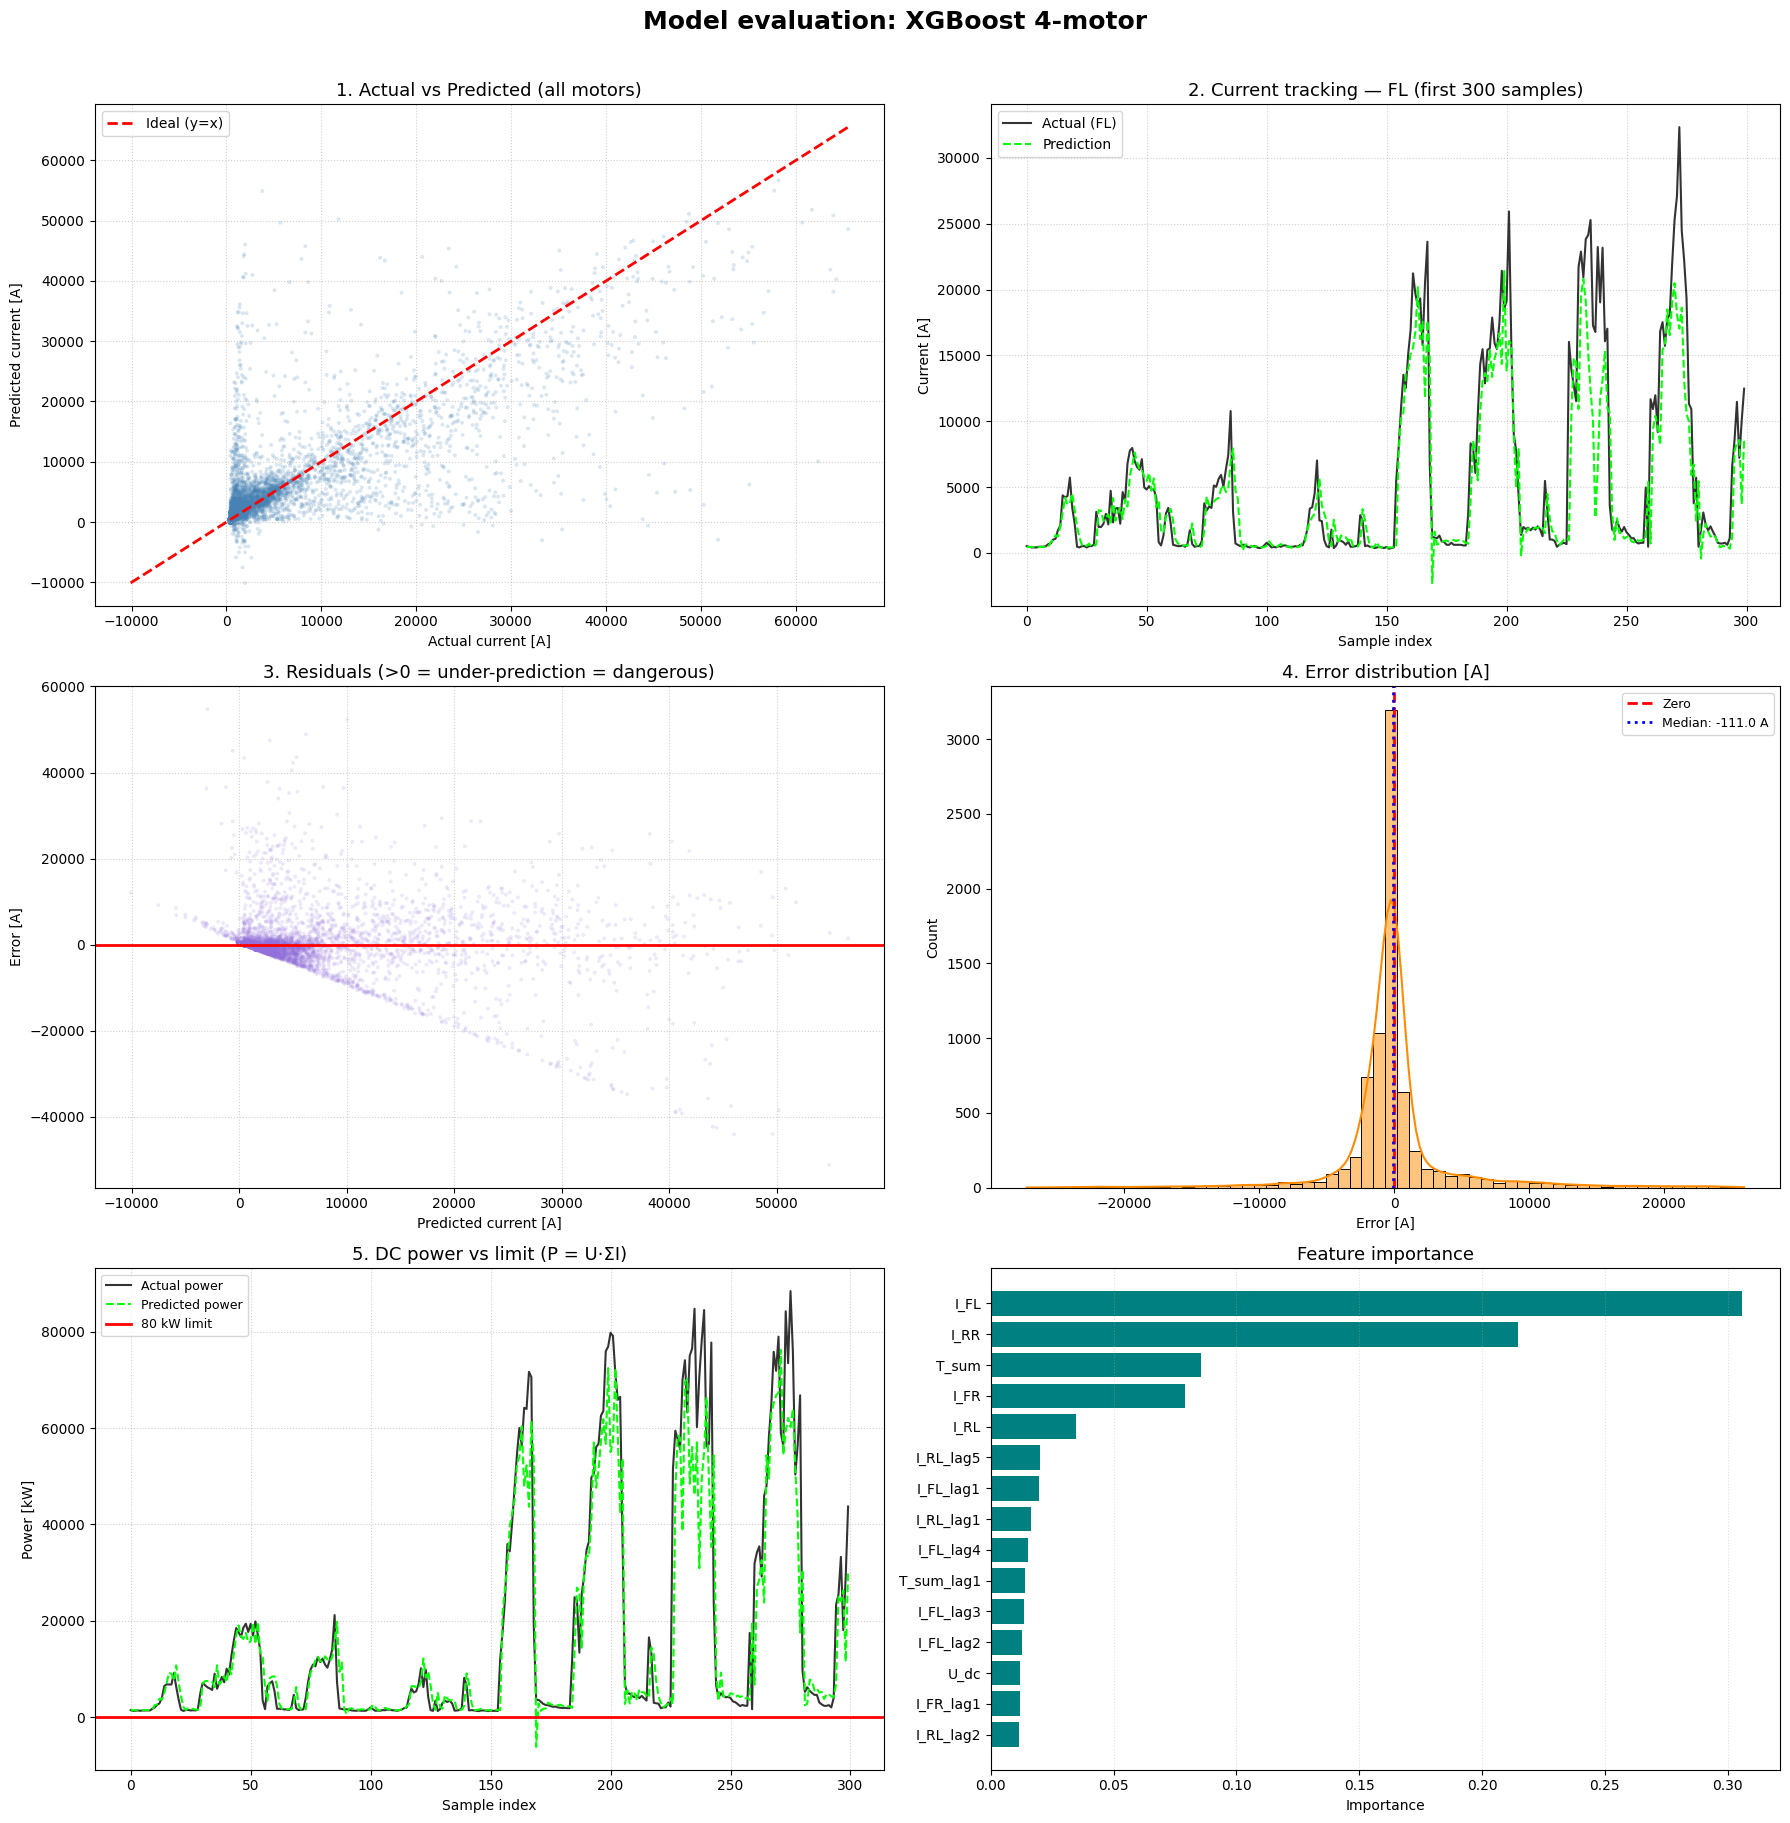

In [7]:
t0 = time.perf_counter()
y_pred = np.column_stack([models[m].predict(X_test) for m in MOTOR_NAMES])
t_infer = time.perf_counter() - t0

metrics = display_model_results(
    'XGBoost 4-motor', y_test, y_pred, t_infer,
    voltage=U_test, motor_names=MOTOR_NAMES, save_to_excel=True,
    feature_importances=models['FL'].feature_importances_,
    feature_names=feature_cols,
)


## 4. Visualization

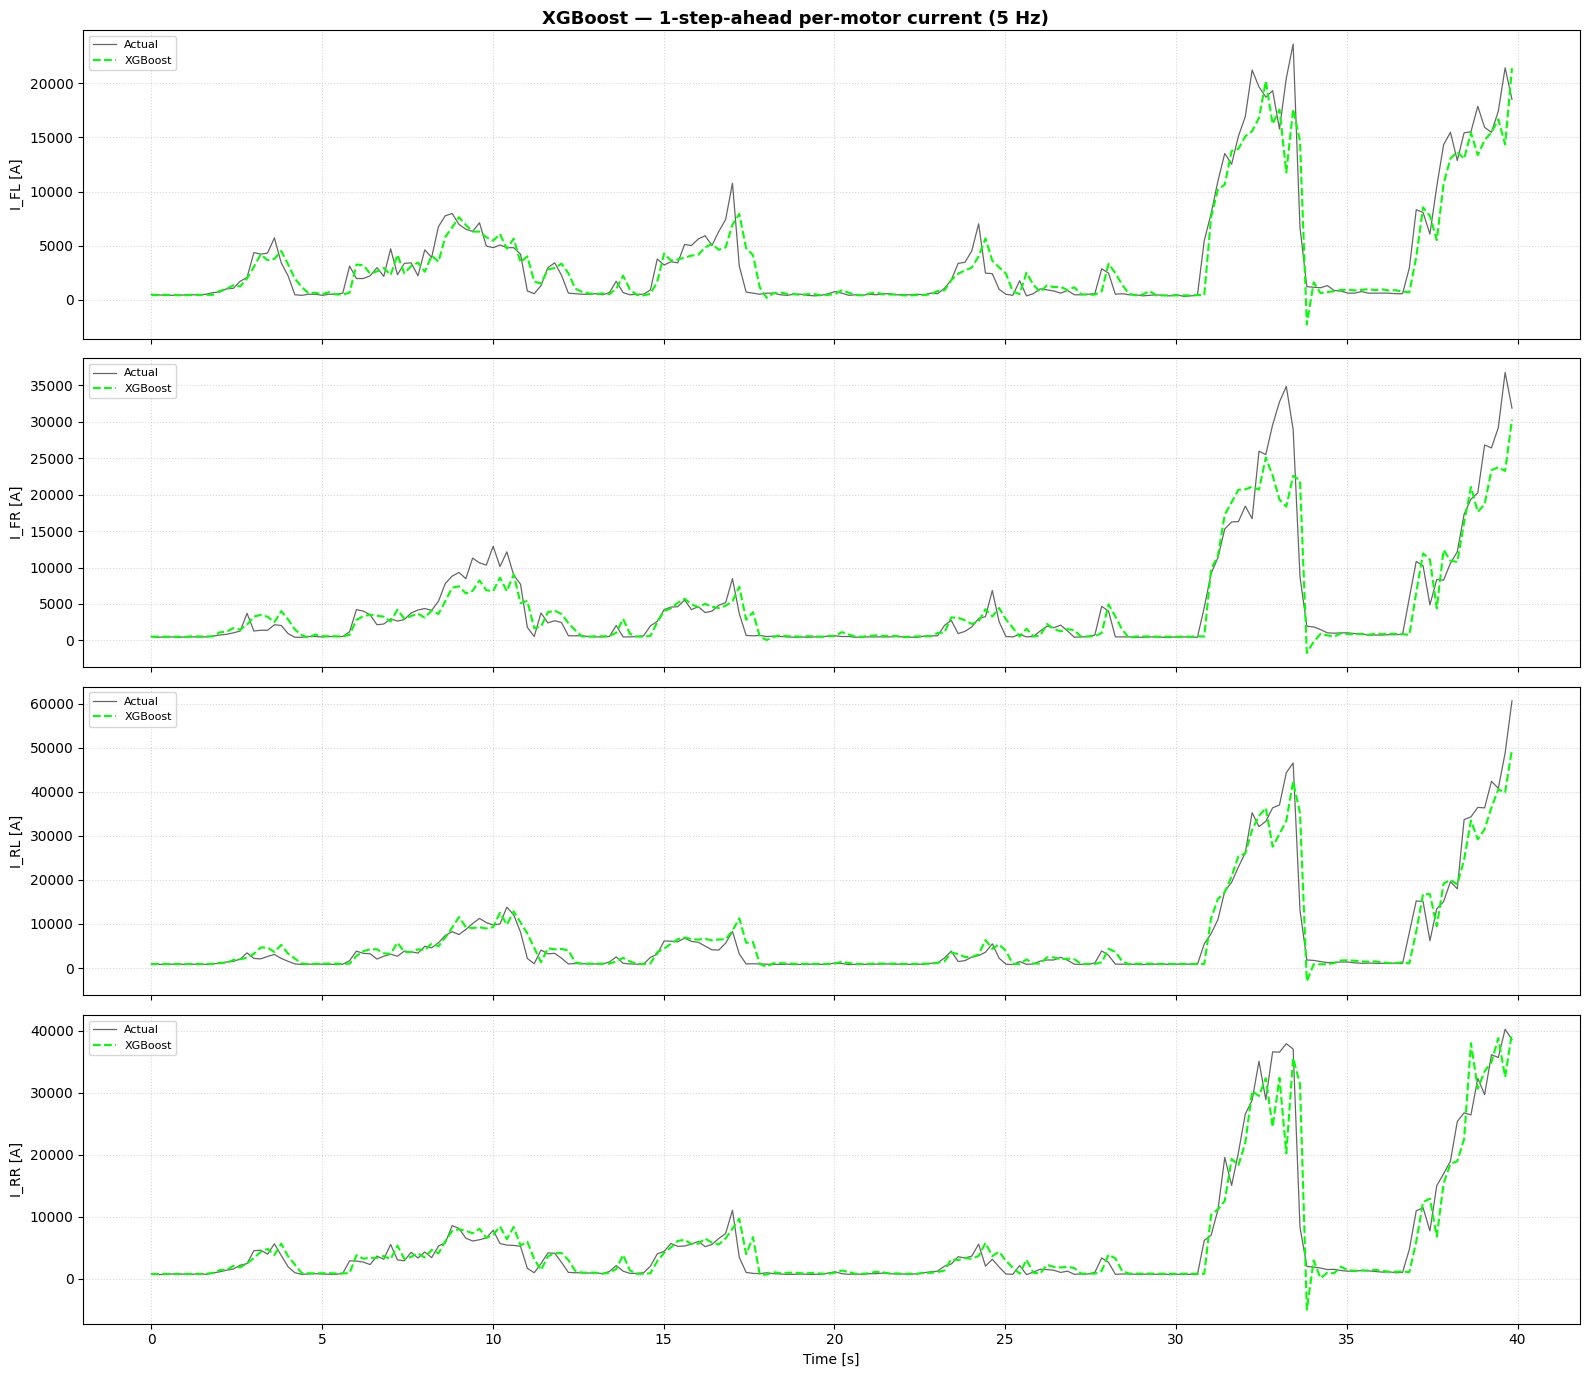

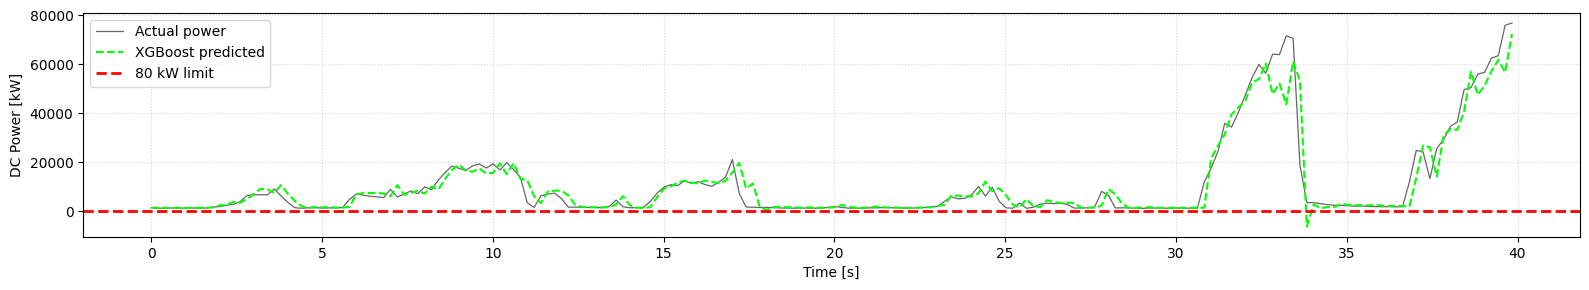

In [8]:
N_PLOT = min(200, len(y_test))
sl     = slice(0, N_PLOT)
t_pl   = t_test[sl] - t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('XGBoost — 1-step-ahead per-motor current (5 Hz)', fontsize=13, fontweight='bold')
for i, (ax, m) in enumerate(zip(axes, MOTOR_NAMES)):
    ax.plot(t_pl, y_test[sl, i], lw=0.9, color='black', alpha=0.6, label='Actual')
    ax.plot(t_pl, y_pred[sl, i], lw=1.5, color='lime',  ls='--',   label='XGBoost')
    ax.set_ylabel(f'I_{m} [A]'); ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.5)
axes[-1].set_xlabel('Time [s]')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 3))
P_true = U_test[sl] * y_test[sl].sum(axis=1) / 1e3
P_pred = U_test[sl] * y_pred[sl].sum(axis=1) / 1e3
ax.plot(t_pl, P_true, lw=0.9, color='black', alpha=0.6, label='Actual power')
ax.plot(t_pl, P_pred, lw=1.5, color='lime',  ls='--',   label='XGBoost predicted')
ax.axhline(POWER_LIMIT_W / 1e3, color='red', lw=2, ls='--', label='80 kW limit')
ax.set_ylabel('DC Power [kW]'); ax.set_xlabel('Time [s]')
ax.legend(); ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()
